In [1]:
# ============================================================
# CELL 0 — Environment Setup (run this first, every session)
# ============================================================
# USE_DRIVE = True  → Google Colab + Google Drive
# USE_DRIVE = False → Local machine  ← DEFAULT
# ============================================================

import os, sys
from pathlib import Path

USE_DRIVE = False  # ← change to True only on Colab + Drive

# ── Auto-detect Colab ────────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Resolve BASE (repo root) ─────────────────────────────────────────────────
if IN_COLAB and USE_DRIVE:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/retail-demand-forecasting')
elif IN_COLAB:
    BASE = Path('/content/dl-assignment')
else:
    # Local: CWD is either repo root or notebooks/ — handle both
    _cwd = Path(os.getcwd())
    BASE = _cwd.parent if _cwd.name == 'notebooks' else _cwd

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH      = BASE / 'data' / 'm5' / 'extracted'
PROCESSED_PATH = BASE / 'data' / 'm5' / 'processed'
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

CALENDAR_PATH = DATA_PATH / 'calendar.csv'
PRICES_PATH   = DATA_PATH / 'sell_prices.csv'
SALES_PATH    = DATA_PATH / 'sales_train_validation.csv'

# ── Add src/ to Python path ───────────────────────────────────────────────────
SRC_PATH = str(BASE / 'src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# ── GPU check ─────────────────────────────────────────────────────────────────
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Environment   : {"Google Colab" if IN_COLAB else "Local"}')
print(f'USE_DRIVE     : {USE_DRIVE}')
print(f'BASE          : {BASE}')
print(f'Device        : {device}')
if torch.cuda.is_available():
    print(f'GPU           : {torch.cuda.get_device_name(0)}')
print(f'DATA_PATH     : {DATA_PATH}')
print(f'DATA exists?  : {DATA_PATH.exists()}')
if not DATA_PATH.exists():
    print()
    print('[WARNING] DATA_PATH not found! Expected M5 CSVs in:')
    print(f'          {DATA_PATH}')


Environment   : Local
USE_DRIVE     : False
BASE          : e:\dl-assignment
Device        : cuda
GPU           : NVIDIA GeForce RTX 3050 6GB Laptop GPU
DATA_PATH     : e:\dl-assignment\data\m5\extracted
DATA exists?  : True


In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
# Install dependencies — only needed on Colab
if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q',
        'pandas', 'numpy', 'matplotlib', 'seaborn',
        'scikit-learn', 'torch', 'torchvision', 'torchaudio',
        'tqdm', 'pyyaml', 'pyarrow'])
else:
    print('[INFO] Local env — skipping pip install.')


[INFO] Local env — skipping pip install.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries loaded successfully")

Libraries loaded successfully


In [5]:
# Create project folders (cross-platform)
for folder in [
    DATA_PATH, PROCESSED_PATH,
    BASE / 'src', BASE / 'results',
    BASE / 'results/figures', BASE / 'results/metrics',
    BASE / 'results/checkpoints',
]:
    folder.mkdir(parents=True, exist_ok=True)
print('Project folders ready.')


Project folders ready.


In [6]:
# List directory structure (cross-platform)
for dirpath, dirnames, filenames in os.walk(BASE):
    depth = len(Path(dirpath).relative_to(BASE).parts)
    if depth > 2: continue
    indent = '  ' * depth
    print(f'{indent}{Path(dirpath).name}/')
    for fname in filenames:
        print(f'{indent}  {fname}')


dl-assignment/
  .gitignore
  README.md
  requirements.txt
  torch-2.6.0+cu124-cp313-cp313-win_amd64.whl
  .git/
    COMMIT_EDITMSG
    config
    description
    FETCH_HEAD
    HEAD
    index
    ORIG_HEAD
    packed-refs
    hooks/
      applypatch-msg.sample
      commit-msg.sample
      fsmonitor-watchman.sample
      post-update.sample
      pre-applypatch.sample
      pre-commit.sample
      pre-merge-commit.sample
      pre-push.sample
      pre-rebase.sample
      pre-receive.sample
      prepare-commit-msg.sample
      push-to-checkout.sample
      sendemail-validate.sample
      update.sample
    info/
      exclude
    logs/
      HEAD
    objects/
    refs/
  .venv/
    .gitignore
    pyvenv.cfg
    etc/
    Include/
    Lib/
    Scripts/
      activate
      activate.bat
      activate.fish
      Activate.ps1
      cffi-gen-src.exe
      deactivate.bat
      debugpy-adapter.exe
      debugpy.exe
      dotenv.exe
      f2py.exe
      fonttools.exe
      httpx.exe
      idna

In [7]:
if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q', '-U', 'kaggle'])
else:
    print('[INFO] Local env — kaggle install skipped. Data already at:', DATA_PATH)


[INFO] Local env — kaggle install skipped. Data already at: e:\dl-assignment\data\m5\extracted


In [8]:
if IN_COLAB:
    import subprocess; subprocess.run(['kaggle', '--version'])
else:
    print('[INFO] Kaggle CLI not needed locally.')


[INFO] Kaggle CLI not needed locally.


In [9]:
if IN_COLAB:
    import subprocess; subprocess.run(['kaggle', 'auth', 'login'])
else:
    print('[INFO] Kaggle auth not needed locally.')


[INFO] Kaggle auth not needed locally.


In [10]:
if IN_COLAB:
    import subprocess
    subprocess.run(['kaggle', 'datasets', 'list', '-s', 'm5 forecasting'])
else:
    print('[INFO] Skipped on local.')


[INFO] Skipped on local.


In [11]:
DATA_PATH.mkdir(parents=True, exist_ok=True)
print('Data folder ready:', DATA_PATH)


Data folder ready: e:\dl-assignment\data\m5\extracted


In [12]:
if IN_COLAB:
    import subprocess
    subprocess.run(['kaggle', 'competitions', 'download',
                    '-c', 'm5-forecasting-accuracy',
                    '-p', str(DATA_PATH.parent)])
else:
    print('[INFO] Dataset already downloaded locally at:', DATA_PATH)


[INFO] Dataset already downloaded locally at: e:\dl-assignment\data\m5\extracted


In [13]:
print('Files in', DATA_PATH.parent)
for f in sorted(DATA_PATH.parent.rglob('*')):
    if f.is_file():
        print(f'  {f.relative_to(DATA_PATH.parent)}  ({f.stat().st_size/1e6:.1f} MB)')


Files in e:\dl-assignment\data\m5
  extracted\calendar.csv  (0.1 MB)
  extracted\sales_train_evaluation.csv  (121.7 MB)
  extracted\sales_train_validation.csv  (120.0 MB)
  extracted\sample_submission.csv  (5.2 MB)
  extracted\sell_prices.csv  (203.4 MB)
  processed\calendar_clean.csv  (0.1 MB)
  processed\sales_train_validation_clean.csv  (120.0 MB)
  processed\sell_prices_clean.csv  (210.2 MB)


In [14]:
if IN_COLAB:
    import zipfile
    zip_path = DATA_PATH.parent / 'm5-forecasting-accuracy.zip'
    if zip_path.exists():
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(DATA_PATH)
        print('Extracted to:', DATA_PATH)
    else:
        print('[INFO] Zip not found — files may already be extracted.')
else:
    print('[INFO] Extraction not needed locally. Files at:', DATA_PATH)


[INFO] Extraction not needed locally. Files at: e:\dl-assignment\data\m5\extracted


In [15]:
print('Files in DATA_PATH:')
if DATA_PATH.exists():
    for f in sorted(DATA_PATH.iterdir()):
        print(f'  {f.name:<45} {f.stat().st_size/1e6:>8.1f} MB')
else:
    print('  [WARNING] DATA_PATH not found:', DATA_PATH)


Files in DATA_PATH:
  calendar.csv                                       0.1 MB
  sales_train_evaluation.csv                       121.7 MB
  sales_train_validation.csv                       120.0 MB
  sample_submission.csv                              5.2 MB
  sell_prices.csv                                  203.4 MB


In [16]:
import pandas as pd

# DATA_PATH is set in Cell 0 — works on both Colab and local
calendar = pd.read_csv(CALENDAR_PATH)
prices   = pd.read_csv(PRICES_PATH)
sales    = pd.read_csv(SALES_PATH)

print('Calendar:', calendar.shape)
print('Prices:  ', prices.shape)
print('Sales:   ', sales.shape)


Calendar: (1969, 14)
Prices:   (6841121, 4)
Sales:    (30490, 1919)


In [17]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [18]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [19]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [20]:
print("===== DATASET SHAPES =====")
print(f"Calendar: {calendar.shape}")
print(f"Sell prices: {prices.shape}")
print(f"Sales: {sales.shape}")


===== DATASET SHAPES =====
Calendar: (1969, 14)
Sell prices: (6841121, 4)
Sales: (30490, 1919)


In [21]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [22]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 263.1 KB


In [23]:
print("Calendar columns:")
print(calendar.columns.tolist())

Calendar columns:
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']


In [24]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [25]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 448.2 MB


In [26]:
print("Number of products:", sales["item_id"].nunique())
print("Number of stores:", sales["store_id"].nunique())
print("Number of departments:", sales["dept_id"].nunique())
print("Number of categories:", sales["cat_id"].nunique())
print("Number of states:", sales["state_id"].nunique())

Number of products: 3049
Number of stores: 10
Number of departments: 7
Number of categories: 3
Number of states: 3


In [27]:
print("Unique stores:")
print(sales["store_id"].unique())

print("\nUnique states:")
print(sales["state_id"].unique())

print("\nUnique categories:")
print(sales["cat_id"].unique())

Unique stores:
<ArrowStringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str

Unique states:
<ArrowStringArray>
['CA', 'TX', 'WI']
Length: 3, dtype: str

Unique categories:
<ArrowStringArray>
['HOBBIES', 'HOUSEHOLD', 'FOODS']
Length: 3, dtype: str


In [28]:
sales_columns = [
    col for col in sales.columns
    if col.startswith("d_")
]

print("Number of daily sales columns:", len(sales_columns))
print("First 5:", sales_columns[:5])
print("Last 5:", sales_columns[-5:])

Number of daily sales columns: 1913
First 5: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last 5: ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


In [29]:
print("===== MISSING VALUES =====")

print("\nCalendar:")
print(calendar.isnull().sum())

print("\nPrices:")
print(prices.isnull().sum())

print("\nSales:")
print(sales.isnull().sum().sort_values(ascending=False).head(20))

===== MISSING VALUES =====

Calendar:
date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

Prices:
store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

Sales:
id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
d_1         0
d_2         0
d_3         0
d_4         0
d_5         0
d_6         0
d_7         0
d_8         0
d_9         0
d_10        0
d_11        0
d_12        0
d_13        0
d_14        0
dtype: int64


In [30]:
print("Calendar duplicate rows:", calendar.duplicated().sum())
print("Prices duplicate rows:", prices.duplicated().sum())
print("Sales duplicate rows:", sales.duplicated().sum())

Calendar duplicate rows: 0


Prices duplicate rows: 0
Sales duplicate rows: 0


In [31]:
print(
    "Duplicate price keys:",
    prices.duplicated(
        subset=["store_id", "item_id", "wm_yr_wk"]
    ).sum()
)

Duplicate price keys: 0


In [32]:
sales[sales_columns].describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
count,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,...,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000
mean,1.070220,1.041292,0.780026,0.833454,0.627944,0.958052,0.918662,1.244080,1.073663,0.838701,...,1.370581,1.586159,1.693670,1.248245,1.232207,1.159167,1.149000,1.328862,1.605838,1.633158
std,5.126689,5.365468,3.667454,4.415141,3.379344,4.785947,5.059495,6.617729,5.917204,4.206199,...,3.740017,4.097191,4.359809,3.276925,3.125471,2.876026,2.950364,3.358012,4.089422,3.812248
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
max,360.000000,436.000000,207.000000,323.000000,296.000000,314.000000,316.000000,370.000000,385.000000,353.000000,...,129.000000,160.000000,204.000000,98.000000,100.000000,88.000000,77.000000,141.000000,171.000000,130.000000


In [33]:
total_units_sold = sales[sales_columns].sum().sum()

print("Total units sold:", total_units_sold)

Total units sold: 65695409


In [34]:
print("Minimum daily unit value:", sales[sales_columns].min().min())
print("Maximum daily unit value:", sales[sales_columns].max().max())
print("Mean daily unit value:", sales[sales_columns].mean().mean())

Minimum daily unit value: 0
Maximum daily unit value: 763
Mean daily unit value: 1.126322153733316


In [35]:
daily_sales = sales[sales_columns].sum(axis=0)

print(daily_sales.head())
print(daily_sales.tail())

d_1    32631
d_2    31749
d_3    23783
d_4    25412
d_5    19146
dtype: int64
d_1909    35343
d_1910    35033
d_1911    40517
d_1912    48962
d_1913    49795
dtype: int64


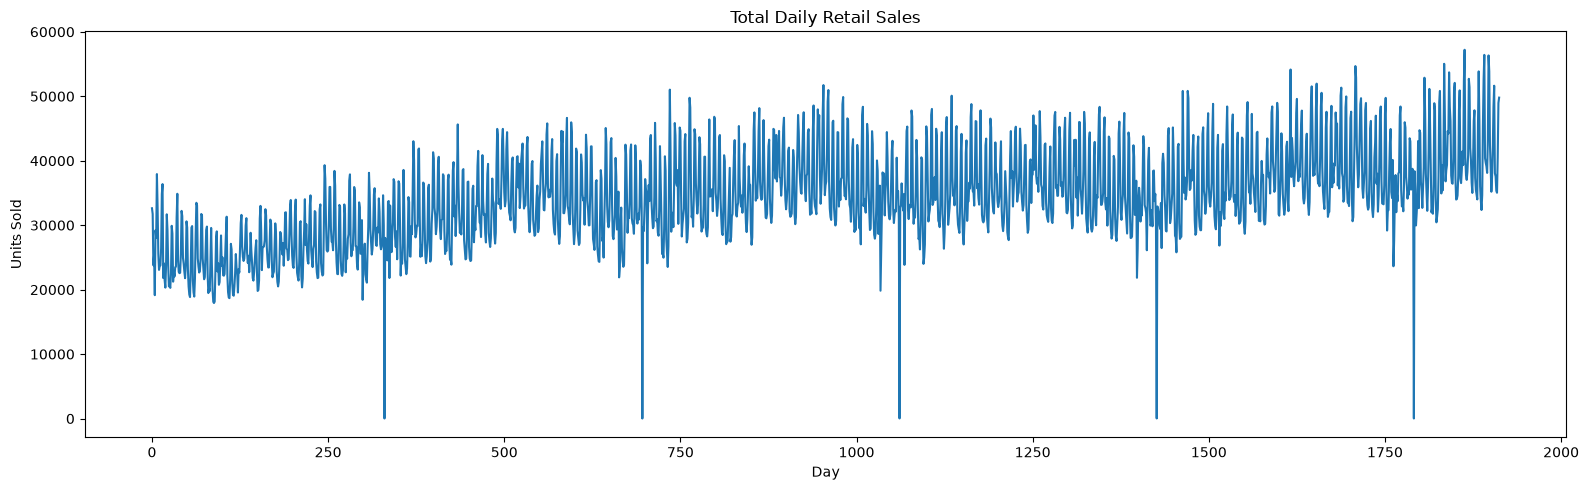

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))

plt.plot(
    range(len(daily_sales)),
    daily_sales.values
)

plt.title("Total Daily Retail Sales")
plt.xlabel("Day")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [37]:
calendar["date"] = pd.to_datetime(calendar["date"])

In [38]:
day_to_date = dict(
    zip(calendar["d"], calendar["date"])
)

In [39]:
daily_sales_dates = pd.Series(
    daily_sales.values,
    index=[day_to_date[d] for d in sales_columns]
)

daily_sales_dates.head()

2011-01-29    32631
2011-01-30    31749
2011-01-31    23783
2011-02-01    25412
2011-02-02    19146
dtype: int64

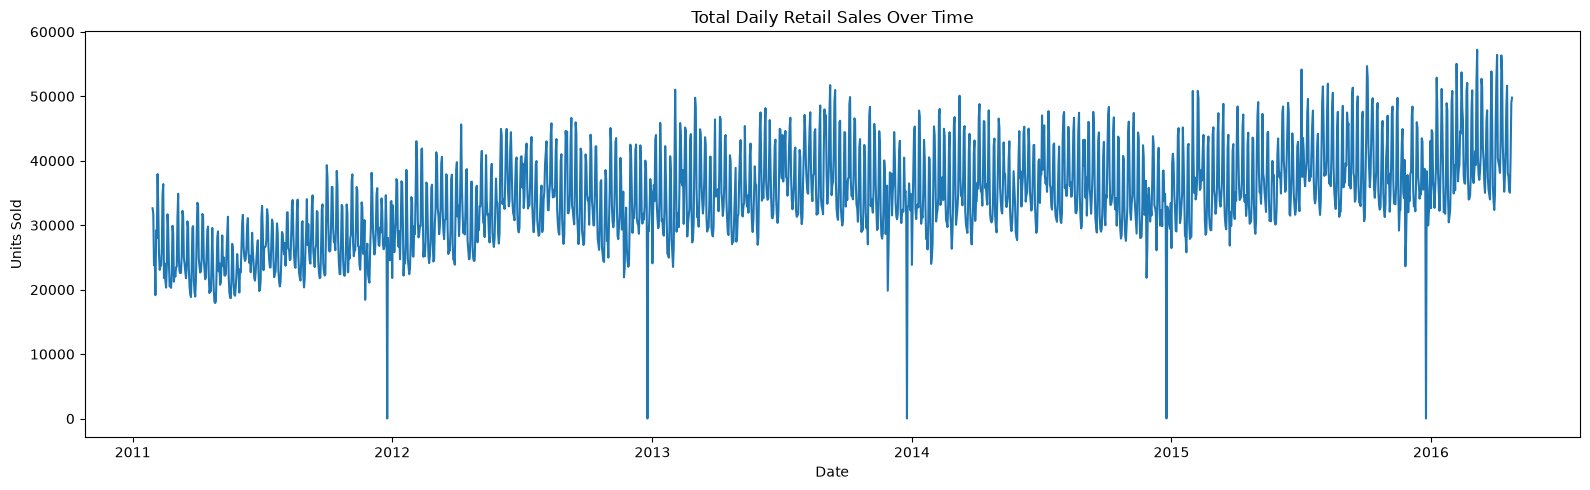

In [40]:
plt.figure(figsize=(16, 5))

plt.plot(
    daily_sales_dates.index,
    daily_sales_dates.values
)

plt.title("Total Daily Retail Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [41]:
daily_sales_df = daily_sales_dates.reset_index()

daily_sales_df.columns = [
    "date",
    "sales"
]

daily_sales_df["month"] = (
    daily_sales_df["date"].dt.to_period("M")
)

In [42]:
monthly_sales = (
    daily_sales_df
    .groupby("month")["sales"]
    .sum()
)

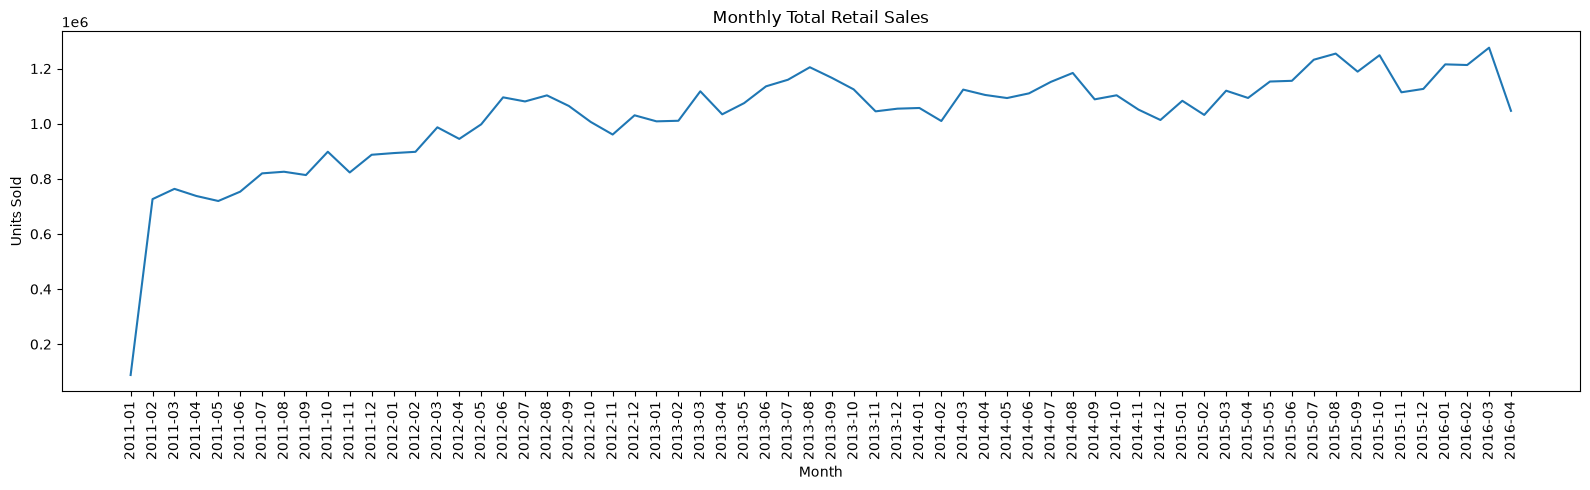

In [43]:
plt.figure(figsize=(16, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

plt.title("Monthly Total Retail Sales")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [44]:
calendar["date"] = pd.to_datetime(calendar["date"])

calendar["day_of_week"] = (
    calendar["date"].dt.day_name()
)

calendar[["d", "date", "day_of_week"]].head()

,d,date,day_of_week
0,d_1,2011-01-29,Saturday
1,d_2,2011-01-30,Sunday
2,d_3,2011-01-31,Monday
3,d_4,2011-02-01,Tuesday
4,d_5,2011-02-02,Wednesday


In [45]:
daily_calendar = calendar[
    calendar["d"].isin(sales_columns)
][["d", "date", "day_of_week"]].copy()

daily_calendar["sales"] = [
    daily_sales[d]
    for d in daily_calendar["d"]
]

In [46]:
weekday_sales = (
    daily_calendar
    .groupby("day_of_week")["sales"]
    .mean()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = weekday_sales.reindex(weekday_order)

weekday_sales

day_of_week
Monday       32852.967033
Tuesday      30368.780220
Wednesday    30010.021978
Thursday     30205.007326
Friday       34225.985348
Saturday     41546.894161
Sunday       41130.021898
Name: sales, dtype: float64

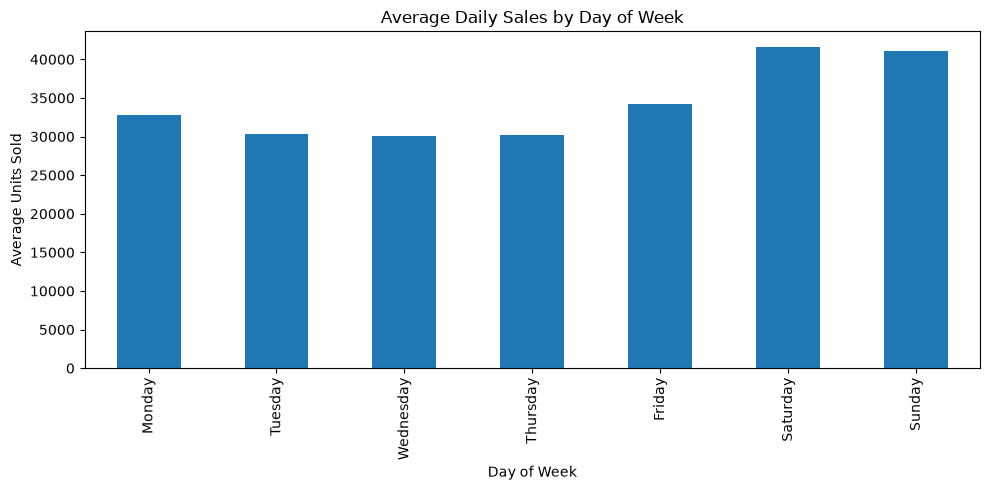

In [47]:
plt.figure(figsize=(10, 5))

weekday_sales.plot(kind="bar")

plt.title("Average Daily Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

In [48]:
print(calendar["event_name_1"].value_counts(dropna=False).head(20))

event_name_1
NaN                1807
SuperBowl             6
ValentinesDay         6
PresidentsDay         6
LentStart             6
LentWeek2             6
StPatricksDay         6
Purim End             6
Pesach End            6
Mother's day          6
MemorialDay           6
NBAFinalsStart        6
NBAFinalsEnd          6
Ramadan starts        6
OrthodoxEaster        5
Cinco De Mayo         5
IndependenceDay       5
Eid al-Fitr           5
LaborDay              5
ColumbusDay           5
Name: count, dtype: int64


In [49]:
print(calendar["event_type_1"].value_counts(dropna=False))

event_type_1
NaN          1807
Religious      55
National       52
Cultural       37
Sporting       18
Name: count, dtype: int64


In [50]:
print(calendar["event_name_2"].value_counts(dropna=False).head(20))

event_name_2
NaN               1964
Father's day         2
Easter               1
Cinco De Mayo        1
OrthodoxEaster       1
Name: count, dtype: int64


In [51]:
prices.describe()

,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02


In [52]:
print("Unique stores:", prices["store_id"].nunique())
print("Unique products:", prices["item_id"].nunique())
print("Unique weeks:", prices["wm_yr_wk"].nunique())

Unique stores: 10
Unique products: 3049
Unique weeks: 282


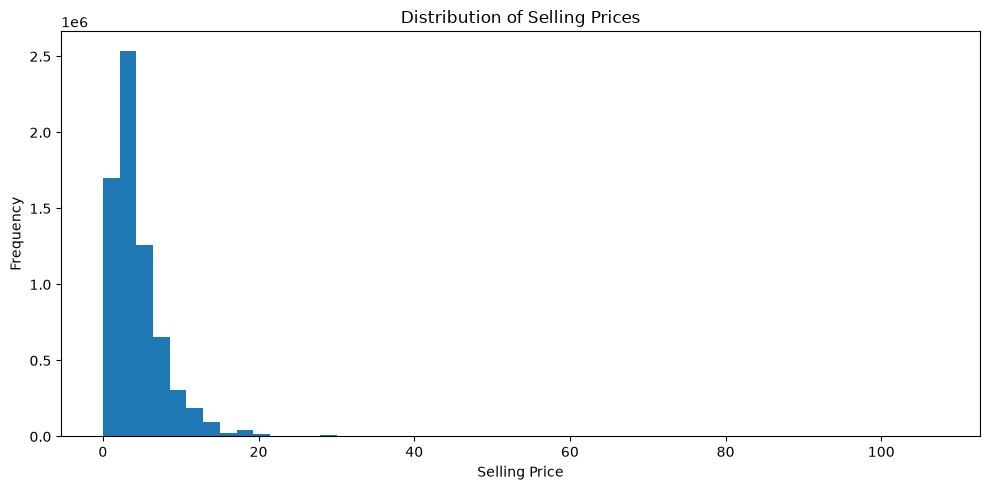

In [53]:
plt.figure(figsize=(10, 5))

plt.hist(
    prices["sell_price"],
    bins=50
)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [54]:
product_sales = (
    sales
    .groupby("item_id")[sales_columns]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

In [55]:
product_sales.head(10)

item_id
FOODS_3_090    1002529
FOODS_3_586     920242
FOODS_3_252     565299
FOODS_3_555     491287
FOODS_3_714     396172
FOODS_3_587     396119
FOODS_3_694     390001
FOODS_3_226     363082
FOODS_3_202     295689
FOODS_3_723     284333
dtype: int64

In [56]:
product_sales.tail(10)

item_id
HOBBIES_2_023      800
HOUSEHOLD_2_307    796
HOUSEHOLD_2_130    789
HOUSEHOLD_2_245    780
HOBBIES_2_111      770
HOUSEHOLD_2_005    757
HOBBIES_2_084      746
HOUSEHOLD_2_175    718
HOBBIES_2_119      660
HOUSEHOLD_2_101    568
dtype: int64

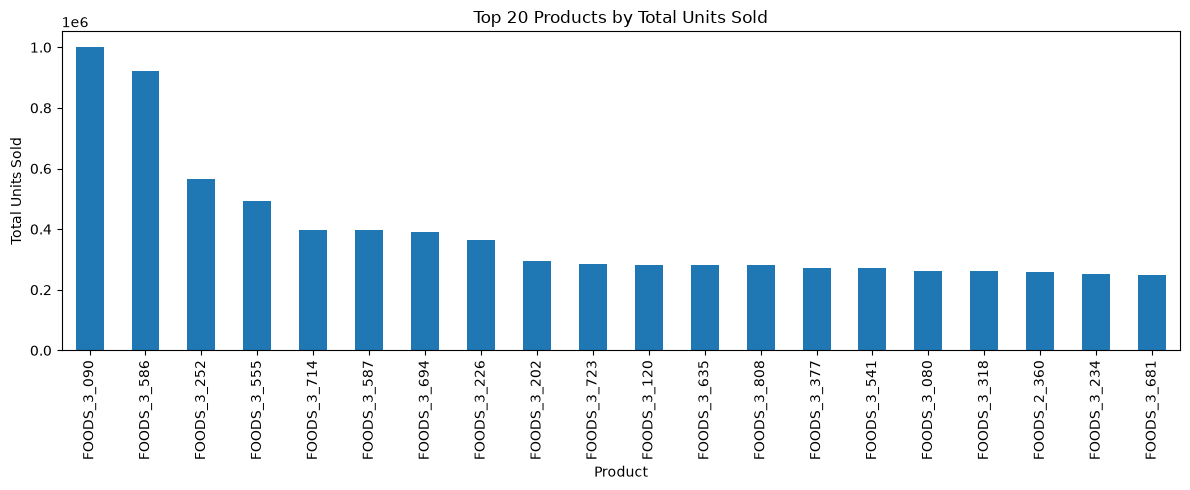

In [57]:
plt.figure(figsize=(12, 5))

product_sales.head(20).plot(kind="bar")

plt.title("Top 20 Products by Total Units Sold")
plt.xlabel("Product")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()

In [58]:
store_sales = (
    sales
    .groupby("store_id")[sales_columns]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

store_sales

store_id
CA_3    11188180
CA_1     7698216
TX_2     7214384
WI_2     6544012
WI_3     6427782
TX_3     6089330
CA_2     5685475
TX_1     5595292
WI_1     5149062
CA_4     4103676
dtype: int64

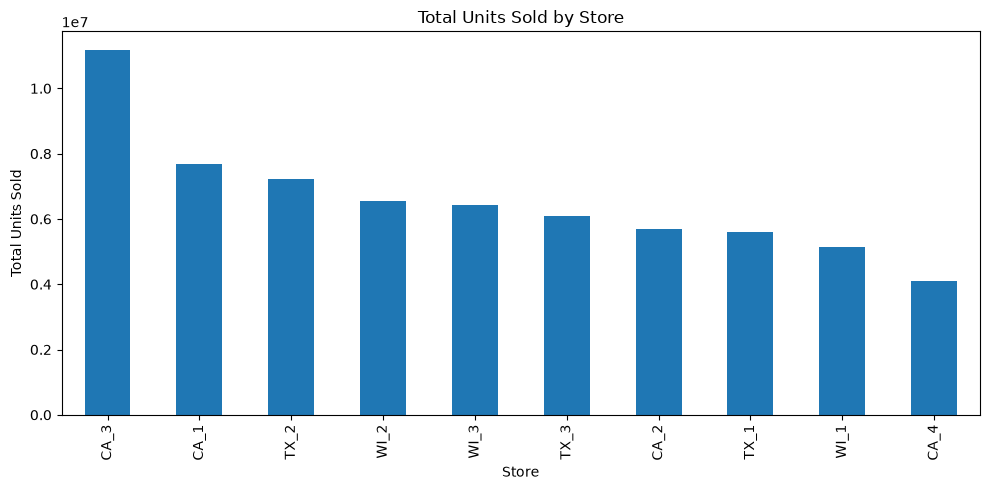

In [59]:
plt.figure(figsize=(10, 5))

store_sales.plot(kind="bar")

plt.title("Total Units Sold by Store")
plt.xlabel("Store")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()

In [60]:
zero_sales_count = (
    sales[sales_columns] == 0
).sum().sum()

total_sales_observations = (
    sales[sales_columns].size
)

zero_sales_percentage = (
    zero_sales_count /
    total_sales_observations
) * 100

print("Zero-sales observations:", zero_sales_count)
print("Total observations:", total_sales_observations)
print(
    f"Zero-sales percentage: {zero_sales_percentage:.2f}%"
)

Zero-sales observations: 39777094
Total observations: 58327370
Zero-sales percentage: 68.20%


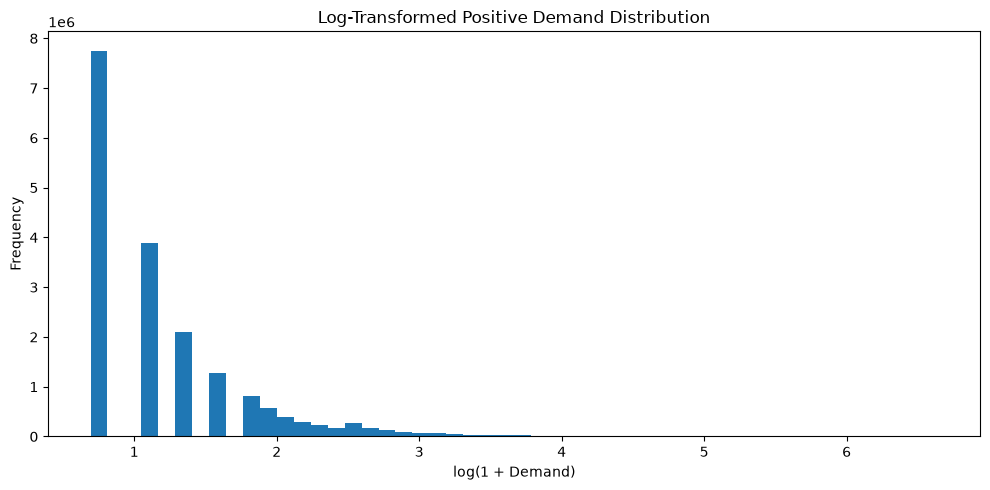

In [61]:
positive_demand = sales[sales_columns].values.flatten()

positive_demand = positive_demand[
    positive_demand > 0
]

log_demand = np.log1p(positive_demand)

plt.figure(figsize=(10, 5))

plt.hist(
    log_demand,
    bins=50
)

plt.title("Log-Transformed Positive Demand Distribution")
plt.xlabel("log(1 + Demand)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [62]:
demand_percentiles = np.percentile(
    positive_demand,
    [25, 50, 75, 90, 95, 99]
)

print("Demand Percentiles")
print("------------------")

for percentile, value in zip(
    [25, 50, 75, 90, 95, 99],
    demand_percentiles
):
    print(f"{percentile}th percentile: {value:.2f}")

Demand Percentiles
------------------
25th percentile: 1.00
50th percentile: 2.00
75th percentile: 4.00
90th percentile: 7.00
95th percentile: 11.00
99th percentile: 28.00


In [63]:
series_statistics = pd.DataFrame({
    "mean_demand": sales[sales_columns].mean(axis=1),
    "std_demand": sales[sales_columns].std(axis=1),
    "total_demand": sales[sales_columns].sum(axis=1),
    "zero_days": (sales[sales_columns] == 0).sum(axis=1)
})

series_statistics["cv"] = (
    series_statistics["std_demand"] /
    series_statistics["mean_demand"].replace(0, np.nan)
)

series_statistics.head()

,mean_demand,std_demand,total_demand,zero_days,cv
0,0.313643,0.685250,600,1492,2.184806
1,0.257710,0.569422,493,1511,2.209541
2,0.150549,0.486557,288,1697,3.231885
3,1.718766,1.989867,3288,617,1.157730
4,0.966545,1.294472,1849,950,1.339278


In [64]:
cv_values = series_statistics["cv"].dropna()

print("Coefficient of Variation Statistics")
print("-----------------------------------")

print(f"Minimum CV: {cv_values.min():.2f}")
print(f"Median CV: {cv_values.median():.2f}")
print(f"Mean CV: {cv_values.mean():.2f}")
print(f"Maximum CV: {cv_values.max():.2f}")

Coefficient of Variation Statistics
-----------------------------------
Minimum CV: 0.25
Median CV: 2.05
Mean CV: 2.39
Maximum CV: 23.03


In [65]:
most_intermittent = series_statistics.sort_values(
    "zero_days",
    ascending=False
).head(10)

most_intermittent[
    ["mean_demand", "std_demand", "total_demand", "zero_days", "cv"]
]

,mean_demand,std_demand,total_demand,zero_days,cv
6682,0.005227,0.096886,10,1906,18.534281
6992,0.009409,0.158165,18,1903,16.809376
6048,0.006273,0.091262,12,1903,14.548753
27606,0.006796,0.082176,13,1900,12.092572
26276,0.008364,0.101933,16,1899,12.187320
6733,0.009932,0.126944,19,1899,12.781222
20192,0.008364,0.106941,16,1899,12.786082
10102,0.011500,0.136734,22,1897,11.889624
26751,0.016205,0.212695,31,1897,13.125368
10214,0.010455,0.116142,20,1896,11.108983


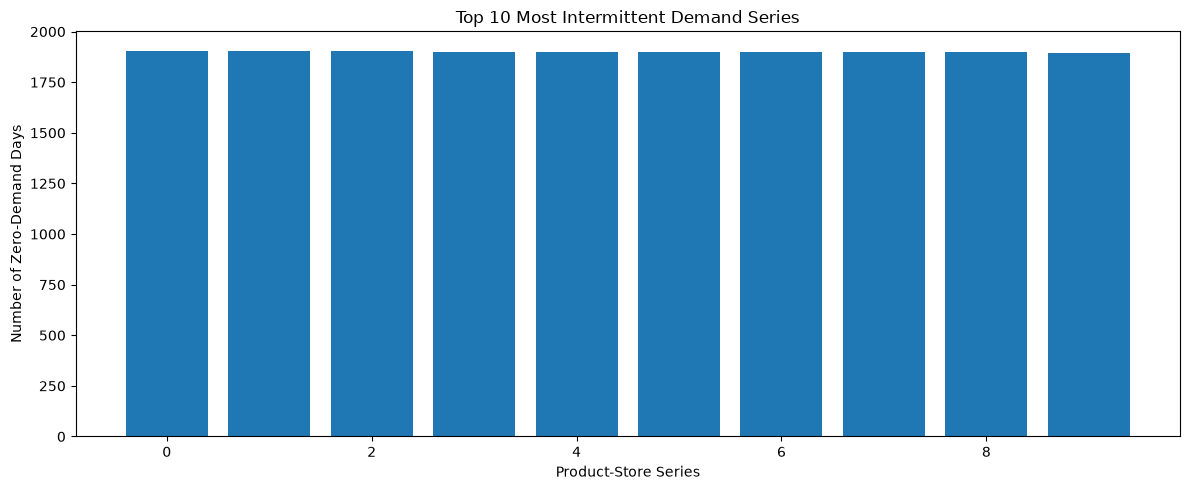

In [66]:
plt.figure(figsize=(12, 5))

plt.bar(
    range(len(most_intermittent)),
    most_intermittent["zero_days"]
)

plt.title("Top 10 Most Intermittent Demand Series")
plt.xlabel("Product-Store Series")
plt.ylabel("Number of Zero-Demand Days")

plt.tight_layout()
plt.show()

In [67]:
daily_sales_df["year"] = (
    daily_sales_df["date"].dt.year
)

yearly_sales = (
    daily_sales_df
    .groupby("year")["sales"]
    .sum()
)

print("Total Sales by Year")
print("-------------------")
print(yearly_sales)

Total Sales by Year
-------------------
year
2011     8856585
2012    12061837
2013    13135753
2014    13089776
2015    13800811
2016     4750647
Name: sales, dtype: int64


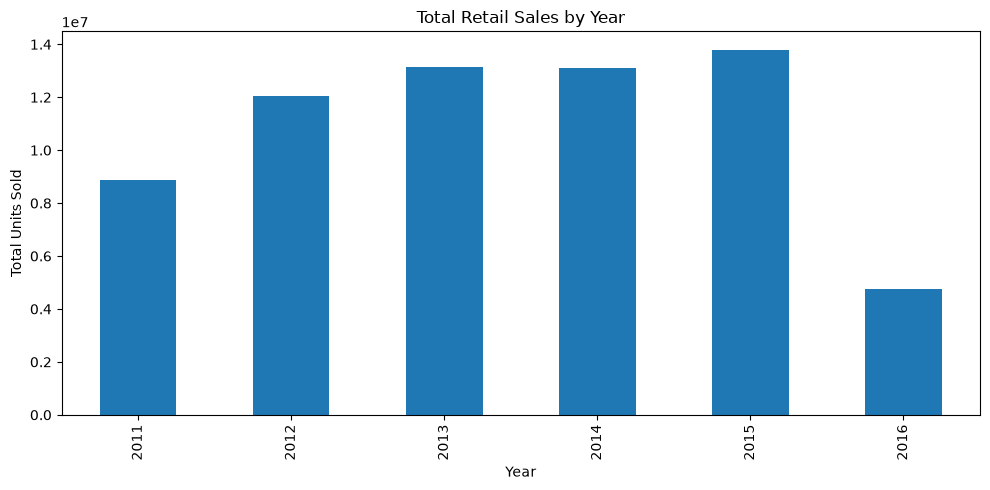

In [68]:
plt.figure(figsize=(10, 5))

yearly_sales.plot(kind="bar")

plt.title("Total Retail Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()

In [69]:
daily_sales_df["month_number"] = (
    daily_sales_df["date"].dt.month
)

monthly_average = (
    daily_sales_df
    .groupby("month_number")["sales"]
    .mean()
)

print("Average Daily Sales by Month")
print("----------------------------")
print(monthly_average)

Average Daily Sales by Month
----------------------------
month_number
1     33832.348101
2     34644.641176
3     34339.838710
4     34258.683908
5     32503.851613
6     35001.413333
7     35122.419355
8     35946.645161
9     35479.260000
10    34713.477419
11    33290.826667
12    32980.464516
Name: sales, dtype: float64


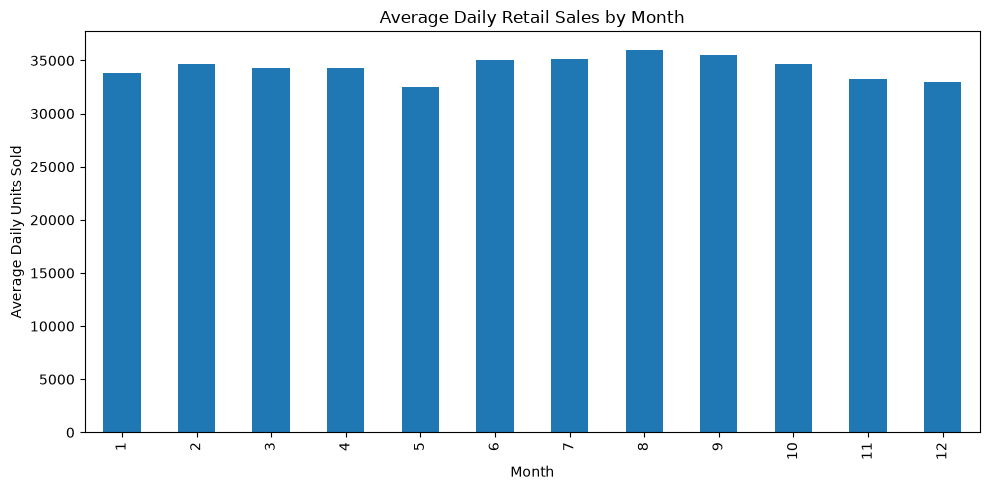

In [70]:
plt.figure(figsize=(10, 5))

monthly_average.plot(
    kind="bar"
)

plt.title("Average Daily Retail Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Units Sold")

plt.tight_layout()
plt.show()

In [71]:
department_sales = (
    sales
    .groupby("dept_id")[sales_columns]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

print("Total Demand by Department")
print("--------------------------")
print(department_sales)

Total Demand by Department
--------------------------
dept_id
FOODS_3        32372076
HOUSEHOLD_1    11500526
FOODS_2         7629822
HOBBIES_1       5596460
FOODS_1         5088041
HOUSEHOLD_2     2980144
HOBBIES_2        528340
dtype: int64


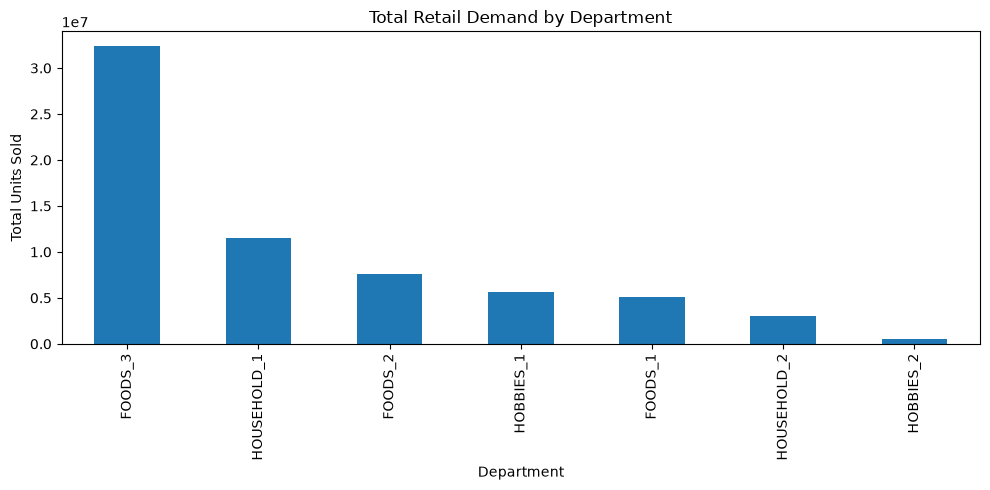

In [72]:
plt.figure(figsize=(10, 5))

department_sales.plot(
    kind="bar"
)

plt.title("Total Retail Demand by Department")
plt.xlabel("Department")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()

In [73]:
category_sales = (
    sales
    .groupby("cat_id")[sales_columns]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

print("Total Demand by Category")
print("------------------------")
print(category_sales)

Total Demand by Category
------------------------
cat_id
FOODS        45089939
HOUSEHOLD    14480670
HOBBIES       6124800
dtype: int64


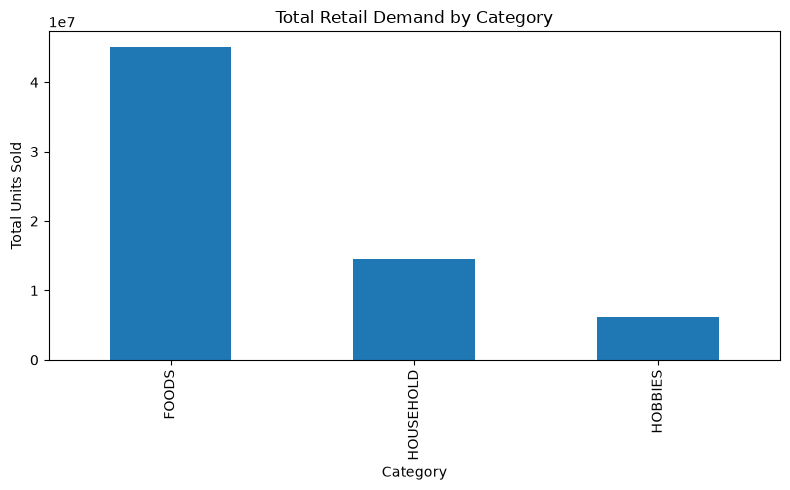

In [74]:
plt.figure(figsize=(8, 5))

category_sales.plot(
    kind="bar"
)

plt.title("Total Retail Demand by Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()

In [75]:
state_sales = (
    sales
    .groupby("state_id")[sales_columns]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

print("Total Demand by State")
print("---------------------")
print(state_sales)

Total Demand by State
---------------------
state_id
CA    28675547
TX    18899006
WI    18120856
dtype: int64


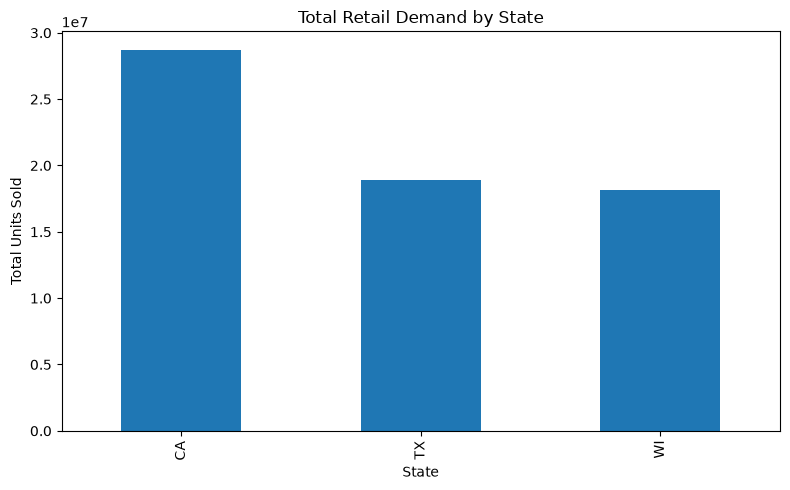

In [76]:
plt.figure(figsize=(8, 5))

state_sales.plot(
    kind="bar"
)

plt.title("Total Retail Demand by State")
plt.xlabel("State")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()

In [77]:
products_per_store = (
    sales
    .groupby("store_id")["item_id"]
    .nunique()
)

print("Number of Products per Store")
print("----------------------------")
print(products_per_store)

Number of Products per Store
----------------------------
store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: item_id, dtype: int64


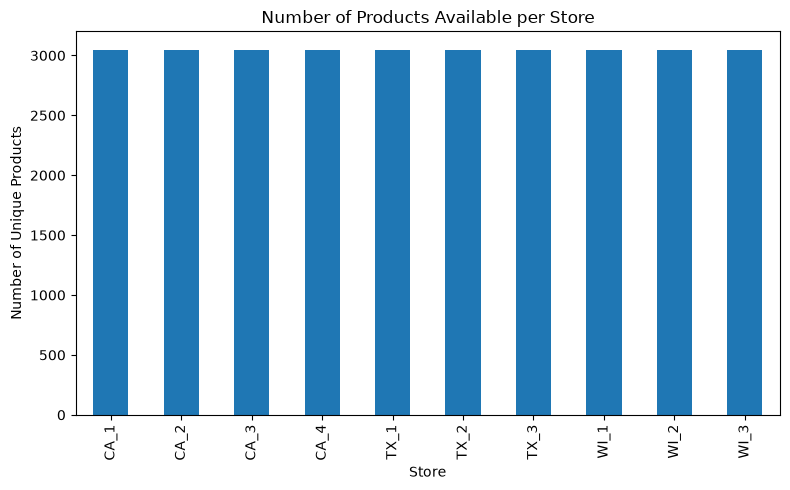

In [78]:
plt.figure(figsize=(8, 5))

products_per_store.plot(
    kind="bar"
)

plt.title("Number of Products Available per Store")
plt.xlabel("Store")
plt.ylabel("Number of Unique Products")

plt.tight_layout()
plt.show()

In [79]:
products_per_category = (
    sales
    .groupby("cat_id")["item_id"]
    .nunique()
)

print("Number of Products per Category")
print("--------------------------------")
print(products_per_category)

Number of Products per Category
--------------------------------
cat_id
FOODS        1437
HOBBIES       565
HOUSEHOLD    1047
Name: item_id, dtype: int64


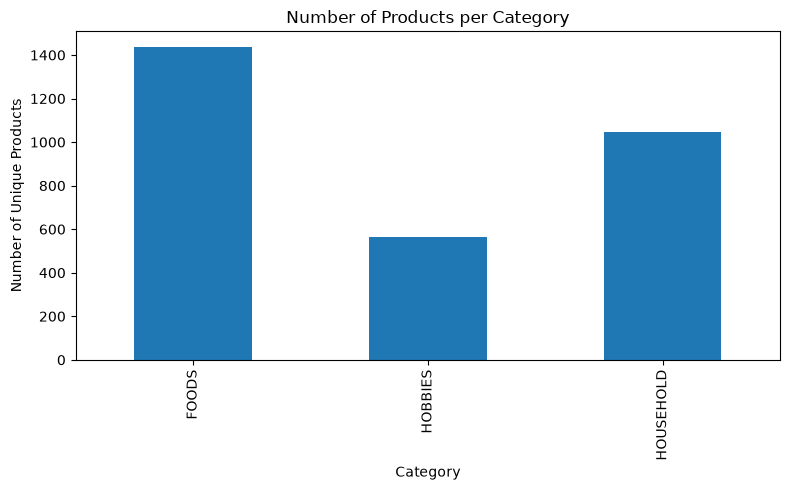

In [80]:
plt.figure(figsize=(8, 5))

products_per_category.plot(
    kind="bar"
)

plt.title("Number of Products per Category")
plt.xlabel("Category")
plt.ylabel("Number of Unique Products")

plt.tight_layout()
plt.show()

In [81]:
weekly_average_price = (
    prices
    .groupby("wm_yr_wk")["sell_price"]
    .mean()
)

print("Weekly Average Selling Price")
print("----------------------------")
print(weekly_average_price.head(10))

Weekly Average Selling Price
----------------------------
wm_yr_wk
11101    4.071247
11102    4.161574
11103    4.190454
11104    4.200812
11105    4.202976
11106    4.201783
11107    4.223439
11108    4.228306
11109    4.231567
11110    4.237505
Name: sell_price, dtype: float64


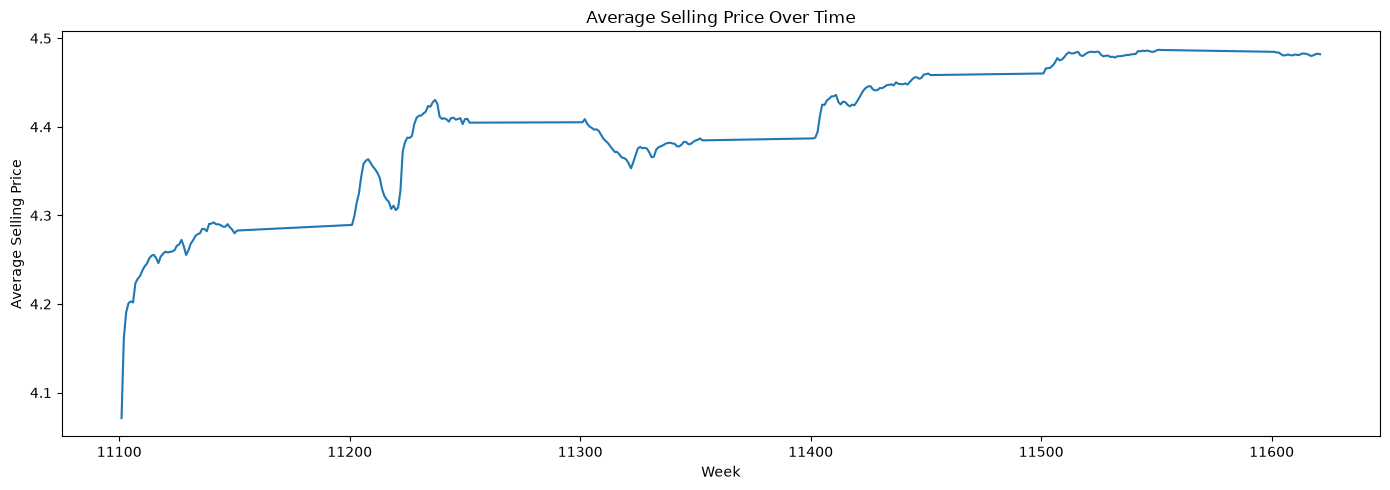

In [82]:
plt.figure(figsize=(14, 5))

plt.plot(
    weekly_average_price.index,
    weekly_average_price.values
)

plt.title("Average Selling Price Over Time")
plt.xlabel("Week")
plt.ylabel("Average Selling Price")

plt.tight_layout()
plt.show()

In [83]:
price_statistics = prices["sell_price"].describe()

print("Selling Price Statistics")
print("------------------------")
print(price_statistics)

Selling Price Statistics
------------------------
count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64


In [84]:
price_std_by_item = (
    prices
    .groupby("item_id")["sell_price"]
    .std()
    .dropna()
)

print("Price variability by product")
print("----------------------------")
print(f"Minimum standard deviation: {price_std_by_item.min():.4f}")
print(f"Median standard deviation: {price_std_by_item.median():.4f}")
print(f"Mean standard deviation: {price_std_by_item.mean():.4f}")
print(f"Maximum standard deviation: {price_std_by_item.max():.4f}")

Price variability by product
----------------------------
Minimum standard deviation: 0.0000
Median standard deviation: 0.1209
Mean standard deviation: 0.1779
Maximum standard deviation: 4.7850


In [85]:
event_calendar = calendar[
    calendar["d"].isin(sales_columns)
].copy()

event_calendar["has_event"] = (
    event_calendar["event_name_1"].notna() |
    event_calendar["event_name_2"].notna()
)

event_calendar["sales"] = [
    daily_sales[d]
    for d in event_calendar["d"]
]

event_demand = (
    event_calendar
    .groupby("has_event")["sales"]
    .mean()
)

print("Average Daily Sales: Event vs Non-Event")
print("---------------------------------------")
print(event_demand)

Average Daily Sales: Event vs Non-Event
---------------------------------------
has_event
False    34489.207504
True     32655.149351
Name: sales, dtype: float64


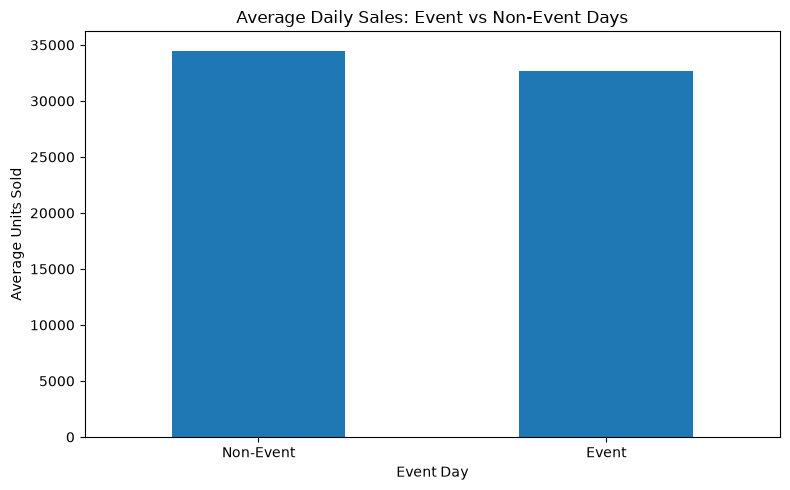

In [86]:
plt.figure(figsize=(8, 5))

event_demand.plot(
    kind="bar"
)

plt.title("Average Daily Sales: Event vs Non-Event Days")
plt.xlabel("Event Day")
plt.ylabel("Average Units Sold")

plt.xticks(
    [0, 1],
    ["Non-Event", "Event"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [87]:
snap_columns = [
    "snap_CA",
    "snap_TX",
    "snap_WI"
]

for column in snap_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(calendar[column].value_counts())


snap_CA
-------
snap_CA
0    1319
1     650
Name: count, dtype: int64

snap_TX
-------
snap_TX
0    1319
1     650
Name: count, dtype: int64

snap_WI
-------
snap_WI
0    1319
1     650
Name: count, dtype: int64


In [88]:
snap_daily = calendar[
    calendar["d"].isin(sales_columns)
].copy()

snap_daily["sales"] = [
    daily_sales[d]
    for d in snap_daily["d"]
]

for column in snap_columns:

    snap_sales = (
        snap_daily
        .groupby(column)["sales"]
        .mean()
    )

    print(f"\nAverage Sales by {column}")
    print(snap_sales)


Average Sales by snap_CA
snap_CA
0    33408.506625
1    36241.738095
Name: sales, dtype: float64

Average Sales by snap_TX
snap_TX
0    33263.012471
1    36538.038095
Name: sales, dtype: float64

Average Sales by snap_WI
snap_WI
0    33239.736555
1    36585.439683
Name: sales, dtype: float64


In [89]:
dataset_summary = {
    "Number of sales series": len(sales),
    "Number of stores": sales["store_id"].nunique(),
    "Number of products": sales["item_id"].nunique(),
    "Number of departments": sales["dept_id"].nunique(),
    "Number of categories": sales["cat_id"].nunique(),
    "Number of states": sales["state_id"].nunique(),
    "Number of historical days": len(sales_columns),
    "Calendar records": len(calendar),
    "Price records": len(prices),
    "Total units sold": int(total_units_sold),
    "Zero-sales percentage": round(zero_sales_percentage, 2)
}

summary_df = pd.DataFrame(
    dataset_summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Number of sales series,30490.0
1,Number of stores,10.0
2,Number of products,3049.0
3,Number of departments,7.0
4,Number of categories,3.0
5,Number of states,3.0
6,Number of historical days,1913.0
7,Calendar records,1969.0
8,Price records,6841121.0
9,Total units sold,65695409.0
